# Week 2: Can a good reconstructor generate new data?
**Deep Generative Models · GDS0058-1 · Practice, not graded**

먼저 **파일 > Drive에 사본 저장**. 이 파일을 Colab에 업로드하여 사본에서 진행합니다. LMS 제출은 없습니다.

**핵심 경로 (60분):** §0 실행 준비 5분 → §1 모델 실행 10분 → §2 세 줄 채우기·복원 해석 10분 → §3 잠재공간·샘플링 15분 → §4 설정 하나 비교 15분 → §5 세 줄 정리 5분.

모델과 학습 코드는 제공됩니다. `backward`나 미분을 이해해야 진행할 수 있는 실습이 아닙니다. 직접 작성할 코드는 **encode, decode, 복원오차 3줄**입니다. 막히면 바로 아래 접힌 정답을 실행하세요. 직접 완성했다면 정답을 건너뛰고 검증 셀을 실행합니다.

CPU로 실행합니다. 기본값은 MNIST 학습 5,000장, 테스트 1,000장, 10 epoch입니다. 실행 속도는 환경에 따라 달라집니다. 다운로드 실패 시 저장된 출력으로 관찰 활동을 하고 연결을 확인한 뒤 다시 실행하세요. 부록은 선택이며 추가 제출이 없습니다.

**오늘의 질문:** 잘 복원하는 것만으로, 어떤 잠재값을 뽑아야 새 데이터가 나오는지 알 수 있을까요?


## 0. Setup / 그대로 실행
MNIST는 공개 손글씨 숫자 데이터입니다. 픽셀은 0~1, 한 이미지는 28×28=784개의 수입니다. 라벨은 그림에 색을 칠할 때만 사용하고 AE 학습에는 사용하지 않습니다.
모델은 원본과 같은 NumPy AE입니다. 데이터 다운로드는 NumPy 파일 하나로 단순화했습니다.


In [1]:
import time, sys, platform, datetime
from pathlib import Path
from urllib.request import urlretrieve
import numpy as np
import matplotlib.pyplot as plt

SEED = 0
EPOCHS = 10
N_TRAIN, N_TEST = 5000, 1000
# CPU의 과도한 스레드 경쟁을 줄입니다. 없어도 실행됩니다.
try:
    from threadpoolctl import threadpool_limits
    thread_limit = threadpool_limits(limits=2)
except ImportError:
    pass

data_path = Path('data/mnist.npz')
data_path.parent.mkdir(exist_ok=True)
if not data_path.exists():
    try:
        urlretrieve('https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz', data_path)
    except Exception as e:
        if data_path.exists(): data_path.unlink()
        raise RuntimeError('MNIST 다운로드 실패. 인터넷을 확인하고 다시 실행하세요. 저장된 출력으로 관찰은 가능합니다.') from e
with np.load(data_path, allow_pickle=False) as data:
    Xtr = data['x_train'][:N_TRAIN].reshape(N_TRAIN, -1).astype(np.float32) / 255.0
    Xte = data['x_test'][:N_TEST].reshape(N_TEST, -1).astype(np.float32) / 255.0
    ytr, yte = data['y_train'][:N_TRAIN], data['y_test'][:N_TEST]
assert Xtr.shape == (N_TRAIN, 784) and Xte.shape == (N_TEST, 784)
assert np.isfinite(Xtr).all() and 0 <= Xtr.min() <= Xtr.max() <= 1
print('Train:', Xtr.shape, 'Test:', Xte.shape, 'CPU, seed:', SEED)


Train: (5000, 784) Test: (1000, 784) CPU, seed: 0


## 1. A supplied autoencoder / 모델 코드는 접어 두어도 됩니다
**슬라이드: The autoencoder / Training by reconstruction**

Encoder는 이미지 784개 수를 잠재값 2개로 줄이고, decoder는 다시 784개 수를 만듭니다. 학습은 입력과 복원 사이 오차를 줄입니다. 두 숫자로 잘 표현되는지는 데이터와 모델에 따라 다릅니다.
아래 두 셀은 그대로 실행합니다. 학습 도중에는 epoch 진행 상황이 표시됩니다.


In [2]:
#@title Supplied model / 제공 모델 (미분 코드는 학습 대상이 아닙니다) { display-mode: "form" }
def sigmoid(a):
    return 1.0 / (1.0 + np.exp(-np.clip(a, -30, 30)))


class Autoencoder:
    def __init__(self, d_in=784, h=128, d_z=2, seed=SEED):
        r = np.random.default_rng(seed)
        he = lambda a, b: r.normal(0, np.sqrt(2 / a), (a, b)).astype(np.float32)
        self.p = {"W1": he(d_in, h), "b1": np.zeros(h, np.float32),      # encoder
                  "W2": he(h, d_z), "b2": np.zeros(d_z, np.float32),     # bottleneck
                  "W3": he(d_z, h), "b3": np.zeros(h, np.float32),       # decoder
                  "W4": he(h, d_in), "b4": np.zeros(d_in, np.float32)}
        # Adam state
        self.m = {k: np.zeros_like(v) for k, v in self.p.items()}
        self.v = {k: np.zeros_like(v) for k, v in self.p.items()}
        self.t = 0

    def encode(self, x):
        p = self.p
        return np.maximum(0, x @ p["W1"] + p["b1"]) @ p["W2"] + p["b2"]

    def decode(self, z):
        p = self.p
        return sigmoid(np.maximum(0, z @ p["W3"] + p["b3"]) @ p["W4"] + p["b4"])

    def forward(self, x):                       # same as encode→decode, but keeps intermediates
        p = self.p
        self.x = x
        self.a1 = x @ p["W1"] + p["b1"];  self.h1 = np.maximum(0, self.a1)
        self.z = self.h1 @ p["W2"] + p["b2"]
        self.a2 = self.z @ p["W3"] + p["b3"]; self.h2 = np.maximum(0, self.a2)
        self.xhat = sigmoid(self.h2 @ p["W4"] + p["b4"])
        return self.xhat

    def backward(self, dxhat):                  # manual backprop; returns gradients
        p, g = self.p, {}
        da4 = dxhat * self.xhat * (1 - self.xhat);       g["W4"] = self.h2.T @ da4; g["b4"] = da4.sum(0)
        da2 = (da4 @ p["W4"].T) * (self.a2 > 0);         g["W3"] = self.z.T @ da2;  g["b3"] = da2.sum(0)
        dz = da2 @ p["W3"].T;                            g["W2"] = self.h1.T @ dz;  g["b2"] = dz.sum(0)
        da1 = (dz @ p["W2"].T) * (self.a1 > 0);          g["W1"] = self.x.T @ da1;  g["b1"] = da1.sum(0)
        return g

    def adam_step(self, g, lr=3e-3, b1=0.9, b2=0.999, eps=1e-8):
        self.t += 1
        for k in self.p:
            self.m[k] = b1 * self.m[k] + (1 - b1) * g[k]
            self.v[k] = b2 * self.v[k] + (1 - b2) * g[k] ** 2
            self.p[k] -= lr * (self.m[k] / (1 - b1 ** self.t)) / (np.sqrt(self.v[k] / (1 - b2 ** self.t)) + eps)

def recon_loss(x, xhat):
    loss = ((xhat - x) ** 2).sum(axis=1).mean()
    dxhat = 2 * (xhat - x) / x.shape[0]
    return loss, dxhat


In [3]:
#@title Supplied training loop / 제공 학습 코드 { display-mode: "form" }
def train_ae(d_z, epochs=EPOCHS, lr=3e-3, batch=128, seed=SEED, verbose=True):
    ae = Autoencoder(d_z=d_z, seed=seed)
    r = np.random.default_rng(seed)
    history = []
    t0 = time.time()
    for ep in range(epochs):
        idx = r.permutation(len(Xtr)); total = 0.0
        for i in range(0, len(Xtr), batch):
            xb = Xtr[idx[i:i + batch]]
            xhat = ae.forward(xb)
            loss, dxhat = recon_loss(xb, xhat)
            ae.adam_step(ae.backward(dxhat), lr=lr)
            total += loss * len(xb)
        history.append(total / len(Xtr))
        if verbose and (ep % 5 == 4 or ep == 0):
            print(f"epoch {ep+1:2d}  train loss {history[-1]:6.1f}")
    test_loss = ((ae.decode(ae.encode(Xte)) - Xte) ** 2).sum(1).mean()
    print(f"d_z={d_z}: test reconstruction error {test_loss:.1f} per image  ({time.time()-t0:.0f}s)")
    return ae, history, test_loss


epoch  1  train loss   81.8
epoch  5  train loss   43.5
epoch 10  train loss   40.6
d_z=2: test reconstruction error 40.0 per image  (1s)
Held-out reconstruction error: 40.02 (sum of squared pixel errors per image)


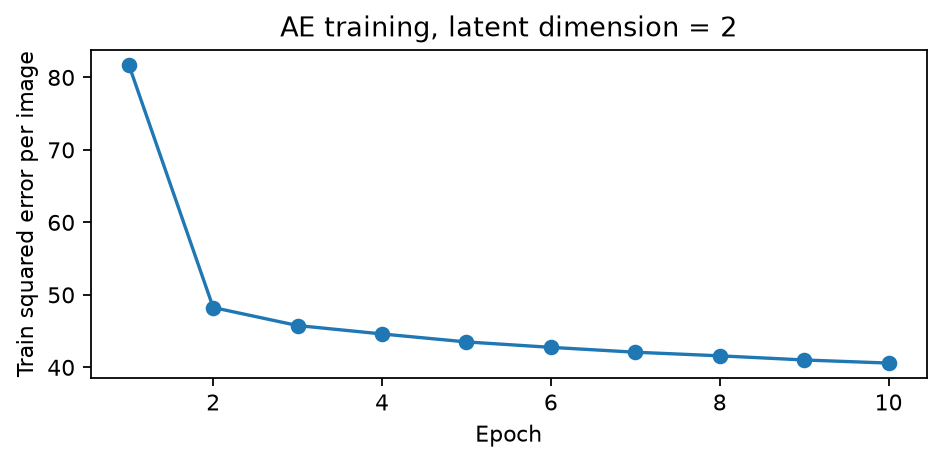

In [4]:
ae2, hist2, test2 = train_ae(d_z=2)
plt.figure(figsize=(6, 3))
plt.plot(range(1, len(hist2)+1), hist2, marker='o')
plt.xlabel('Epoch'); plt.ylabel('Train squared error per image')
plt.title('AE training, latent dimension = 2'); plt.tight_layout(); plt.show()
print('Held-out reconstruction error:', round(float(test2), 3), '(sum of squared pixel errors per image)')


**What to notice.** A falling training loss means the model is improving reconstruction on its training data. Held-out images check whether this also works on unseen inputs.
> 요약: 학습오차 감소는 복원 학습의 결과입니다. 생성 품질이나 이상 탐지 성능을 직접 증명하지는 않습니다.


## 2. Three lines: compress, reconstruct, compare
**슬라이드: Reconstruction on unseen images / Lab: three lines**

`z = model.encode(x)`는 압축, `xhat = model.decode(z)`는 복원입니다.
복원오차는 **픽셀별 차이 제곱을 더한 뒤 이미지별 평균**으로 계산합니다. 여기서는 784픽셀 전체 평균 MSE와 784배 차이가 나므로 단위를 함께 읽으세요.

아래 함수 안에 3줄을 작성합니다. 힌트: `model.encode(x)`, `model.decode(z)`, `((xhat-x)**2).sum(axis=1).mean()`.
함수 정의만 실행하면 오류가 나지 않습니다. 빈칸인 상태로 검증하면 안내형 오류가 납니다.


In [5]:
# TODO: compress, reconstruct, measure (3 lines)
def reconstruct_and_score(model, x):
    """Instructions:
        1. Encode x, decode z, and calculate squared error per image.
        2. Match the slide 'Lab: three lines'.
    Args:
        model: supplied Autoencoder.
        x: float32 array, shape (B, 784), B > 0.
    Returns:
        z: (B, d_z), xhat: (B, 784), error: scalar.
    """
    ###################################################################
    raise NotImplementedError('정상입니다. 의도된 빈칸입니다. 힌트의 3줄을 작성하거나 아래 정답 셀을 실행하세요. / Fill 3 lines or run Solution.')
    ###################################################################
    return z, xhat, error


In [6]:
#@title Solution / 정답 (직접 완성했다면 건너뛰세요) { display-mode: "form" }
def reconstruct_and_score(model, x):
    z = model.encode(x)
    xhat = model.decode(z)
    error = ((xhat-x)**2).sum(axis=1).mean()
    return z, xhat, error


In [7]:
# 내가 작성했다면 정답 셀을 건너뛰고 여기서 먼저 검사합니다.
class ToyModel:
    def encode(self, x): return x[:, :2]
    def decode(self, z):
        assert z.shape[1] == 2, 'decode에는 x가 아니라 encode의 출력 z를 넣으세요.'
        return np.zeros((len(z), 4), dtype=z.dtype)
toy = np.array([[1., 2., 0., 0.], [0., 0., 3., 4.]], dtype=np.float32)
zt, rt, et = reconstruct_and_score(ToyModel(), toy)
assert np.array_equal(zt, toy[:, :2]), 'encode의 입력과 출력을 확인하세요.'
assert np.array_equal(rt, np.zeros_like(toy)), 'decode에는 z를 넣으세요.'
assert np.ndim(et) == 0, '오차는 숫자 하나여야 합니다. 이미지별 제곱합 뒤에 .mean()으로 평균하세요.'
assert np.isclose(et, 15.0), '픽셀별 제곱합 후 이미지별 평균입니다. 전체 픽셀 평균과 다릅니다.'
z_check, xhat_check, error_check = reconstruct_and_score(ae2, Xte[:20])
assert z_check.shape == (20, 2) and xhat_check.shape == (20, 784)
assert np.isfinite(error_check) and xhat_check.dtype == np.float32
print('OK: encode, decode, error. First 20 test images:', round(float(error_check), 3))


OK: encode, decode, error. First 20 test images: 40.348


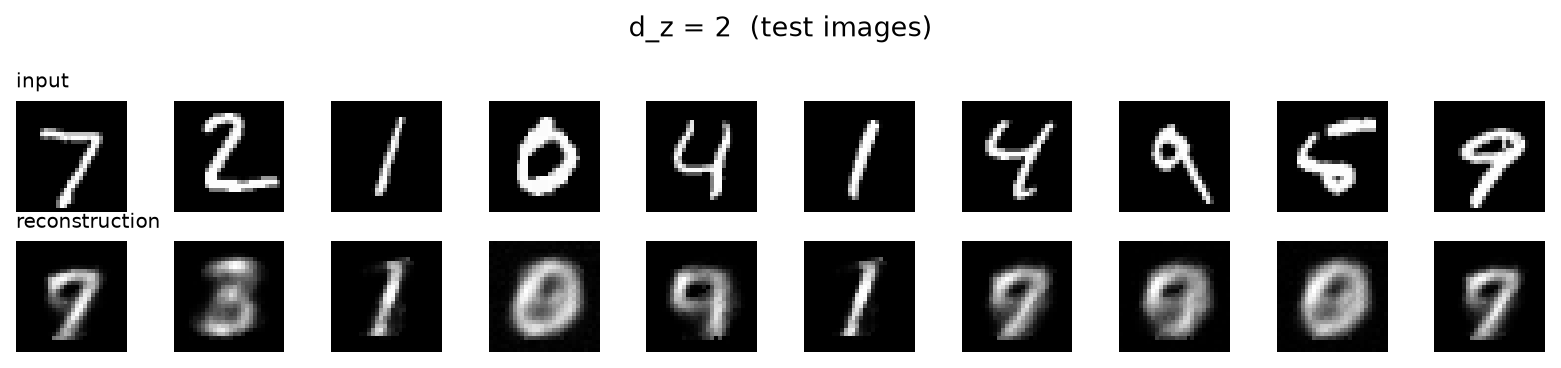

In [8]:
def show_pairs(ae, X, n=10, title=""):
    xhat = ae.decode(ae.encode(X[:n]))
    fig, axes = plt.subplots(2, n, figsize=(n, 2.3))
    for k in range(n):
        axes[0, k].imshow(X[k].reshape(28, 28), cmap="gray");    axes[0, k].axis("off")
        axes[1, k].imshow(xhat[k].reshape(28, 28), cmap="gray"); axes[1, k].axis("off")
    axes[0, 0].set_title("input", fontsize=9, loc="left"); axes[1, 0].set_title("reconstruction", fontsize=9, loc="left")
    fig.suptitle(title); plt.tight_layout(); plt.show()

show_pairs(ae2, Xte, title="d_z = 2  (test images)")


**What to notice.** Compare the top and bottom rows. Which strokes survive? Which digits become ambiguous? Record what you actually see.
> 요약: 복원된 그림을 보고 유지된 특징과 사라진 특징을 각각 하나씩 말해 보세요. 흐릿함의 정도나 숫자 인식 가능성은 실행 결과에 따라 다릅니다.


## 3. Where should new latent values come from?
**슬라이드: The encoded cloud / Sampling new latent values**

색은 정답 숫자 라벨이고, AE는 이 라벨 없이 학습했습니다. 같은 숫자가 완벽하게 분리될 필요는 없습니다.
인코더가 실제로 만든 좌표와 우리가 임의로 뽑은 좌표를 같은 그림에서 비교합니다.


Latent mean: [ 2.06 -1.65] std: [1.92 1.46]


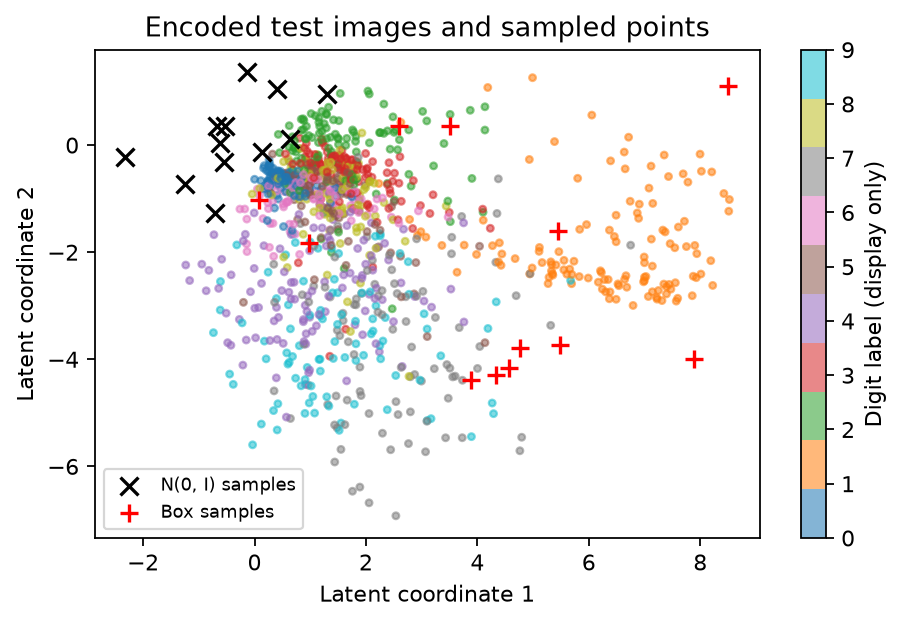

In [9]:
Z = ae2.encode(Xte)
rng = np.random.default_rng(SEED)
z_gauss = rng.normal(size=(12, 2)).astype(np.float32)
lo, hi = Z.min(0), Z.max(0)
z_box = rng.uniform(lo, hi, size=(12, 2)).astype(np.float32)
fig, ax = plt.subplots(figsize=(6, 4))
sc = ax.scatter(Z[:, 0], Z[:, 1], c=yte, cmap='tab10', s=9, alpha=.55)
ax.scatter(z_gauss[:, 0], z_gauss[:, 1], marker='x', s=65, c='black', label='N(0, I) samples')
ax.scatter(z_box[:, 0], z_box[:, 1], marker='+', s=70, c='red', label='Box samples')
fig.colorbar(sc, ax=ax, ticks=range(10), label='Digit label (display only)')
ax.set(xlabel='Latent coordinate 1', ylabel='Latent coordinate 2', title='Encoded test images and sampled points')
ax.legend(fontsize=8); plt.tight_layout(); plt.show()
print('Latent mean:', Z.mean(0).round(2), 'std:', Z.std(0).round(2))


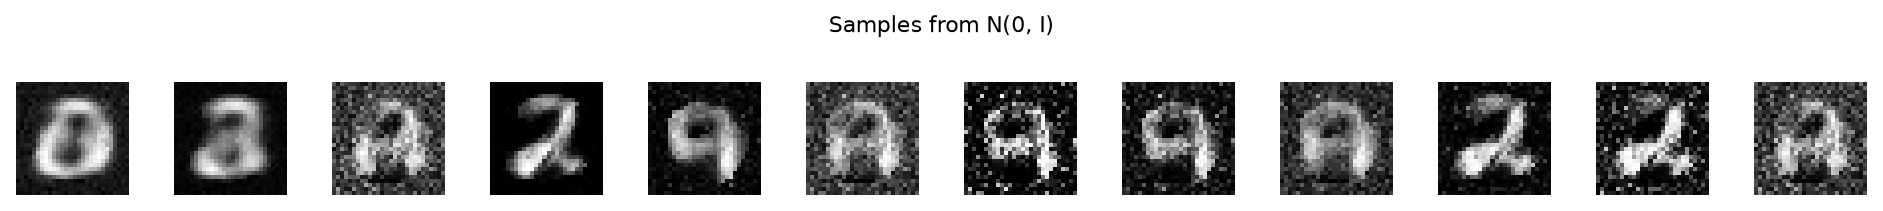

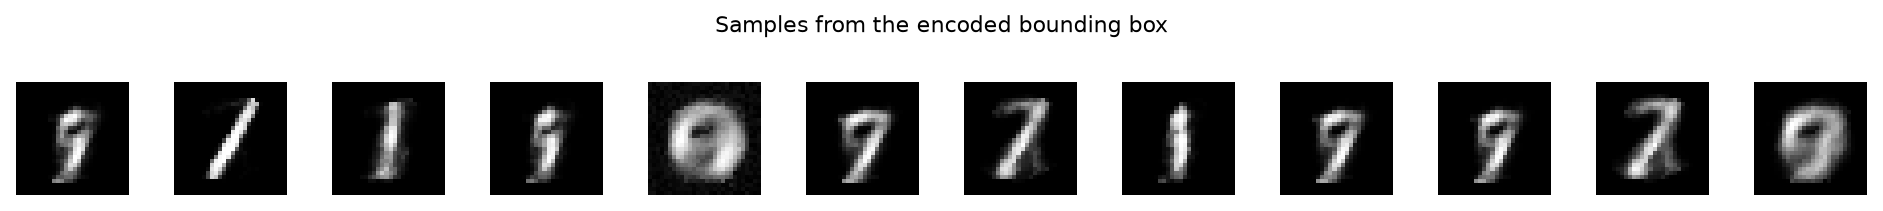

In [10]:
def show_grid(imgs, title):
    n = len(imgs)
    fig, axes = plt.subplots(1, n, figsize=(n, 1.3))
    for k, ax in enumerate(axes):
        ax.imshow(imgs[k].reshape(28, 28), cmap="gray"); ax.axis("off")
    fig.suptitle(title, fontsize=10); plt.tight_layout(); plt.show()


show_grid(ae2.decode(z_gauss), 'Samples from N(0, I)')
show_grid(ae2.decode(z_box), 'Samples from the encoded bounding box')


**What to notice.** Compare variety and recognizability in both rows. Either method can produce some plausible digits. Neither rule was learned or validated by reconstruction training alone. A bounding box can include sparse regions, and a standard normal can miss much of the encoded cloud.
> 요약: “AE는 생성이 불가능하다”가 아니라 **복원 학습만으로 좋은 샘플링 규칙까지 정해지지는 않는다**가 결론입니다. 일부 그럴듯한 결과만으로 전체 생성 품질을 판단하지 마세요. VAE도 모든 잠재값에서 좋은 결과를 보장하지 않습니다.


## 4. Change one setting / 병목 크기 하나 비교 (15 min)
**슬라이드: Bottleneck size / Lab: one controlled comparison**

기본 실험은 `2 → 8` 한 번입니다. 실행 후 아래 `COMPARE_DIM`을 바꾸어 32도 선택적으로 관찰할 수 있습니다. 학습 데이터, seed, epoch는 고정합니다. test 결과는 수업 비교용이며 반복 선택에 쓰면 더 이상 독립 최종평가가 아닙니다.


d_z=8: test reconstruction error 23.3 per image  (1s)
Latent dimension -> held-out squared error per image: {2: 40.02006149291992, 8: 23.250917434692383}


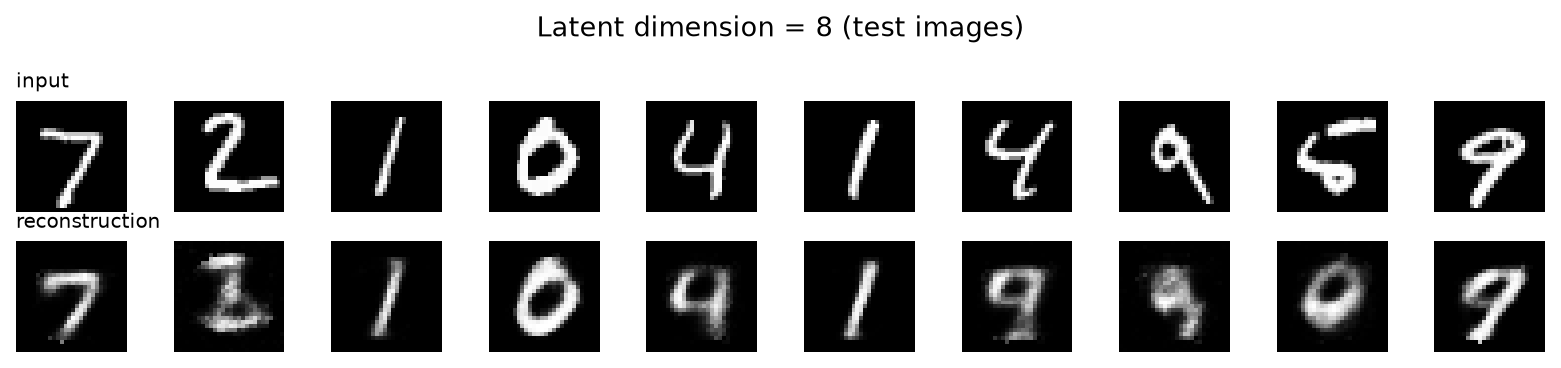

In [11]:
COMPARE_DIM = 8  # 선택: 32. 기본 수업은 8 한 번만.
assert isinstance(COMPARE_DIM, int) and 1 <= COMPARE_DIM <= 64, '1~64의 정수를 사용하세요.'
ae_compare, hist_compare, test_compare = train_ae(d_z=COMPARE_DIM, verbose=False)
results = {2: float(test2), COMPARE_DIM: float(test_compare)}
print('Latent dimension -> held-out squared error per image:', results)
show_pairs(ae_compare, Xte, title=f'Latent dimension = {COMPARE_DIM} (test images)')


**What to notice.** A wider bottleneck can preserve more detail, but the observed effect depends on training. Lower reconstruction error does not establish better random sampling.
> 요약: 오차가 실제로 줄었는지 수치와 그림으로 확인하세요. 8차원 전체를 2축 산점도 하나로 표현할 수는 없습니다. 두 축 선택이나 차원축소로 일부만 볼 수 있습니다.

질문: (1) 오차가 얼마나 변했나요? (2) 어떤 획이 달라졌나요? (3) 이 결과만으로 생성이 좋아졌다고 말할 수 있나요?


## 5. Three lines + environment / 수업 내 정리
무엇을 바꿨는가, 핵심 수치, 한 줄 해석을 직접 적습니다. 실습은 비채점·제출 없음입니다. 과제에서 사용할 형식만 연습합니다.
오늘 핵심 경로는 여기까지입니다. 부록은 선택입니다.


In [12]:
print('Runtime:', platform.platform(), 'Python:', sys.version.split()[0])
print('NumPy:', np.__version__, 'Compute: CPU', 'Seed:', SEED)
print('Executed at:', datetime.datetime.now().astimezone().isoformat(timespec='minutes'))
print('Training examples:', N_TRAIN, 'Test examples:', N_TEST, 'Epochs:', EPOCHS)
print('Observed results:', results)
summary = {'What I changed': '직접 작성', 'Main number': '직접 작성', 'One-line interpretation': '직접 작성'}
for k, v in summary.items(): print(k + ': ' + v)


Runtime: Windows-11-10.0.26200-SP0 Python: 3.12.14
NumPy: 2.5.3 Compute: CPU Seed: 0
Executed at: 2026-09-08T22:56+09:00
Training examples: 5000 Test examples: 1000 Epochs: 10
Observed results: {2: 40.02006149291992, 8: 23.250917434692383}
What I changed: 직접 작성
Main number: 직접 작성
One-line interpretation: 직접 작성


## Optional A. Surprise, cross-entropy and KL
**슬라이드: Average surprise / KL as extra average surprise**

가상의 데이터에서 A가 80%, B가 20%입니다. 좋은 모델과 다른 모델의 평균 놀라움을 비교합니다. 로그는 자연로그이며 단위는 nats입니다. `p`와 `q`는 여기서는 두 범주의 확률입니다.


In [13]:
p = np.array([.8, .2])
q = np.array([.5, .5])  # 선택: [.8, .2] 또는 [.2, .8]
def discrete_scores(p, q):
    p, q = np.asarray(p, dtype=float), np.asarray(q, dtype=float)
    assert p.shape == q.shape and np.all(p >= 0) and np.all(q > 0), '같은 길이의 확률 배열, q>0이 필요합니다.'
    assert np.isclose(p.sum(), 1) and np.isclose(q.sum(), 1), '각 배열 합은 1이어야 합니다.'
    mask = p > 0
    entropy = -np.sum(p[mask] * np.log(p[mask]))
    cross_entropy = -np.sum(p[mask] * np.log(q[mask]))
    return entropy, cross_entropy, cross_entropy - entropy
H, CE, KL = discrete_scores(p, q)
print(f'Entropy={H:.4f}, cross-entropy={CE:.4f}, KL={KL:.4f} nats')
assert np.isclose(discrete_scores(p, p)[2], 0)
assert KL >= -1e-12


Entropy=0.5004, cross-entropy=0.6931, KL=0.1927 nats


**What to notice.** Entropy stays fixed when only q changes. Cross-entropy and KL move by the same amount.
> 요약: 데이터를 고정하면 모델 때문에 추가되는 평균 놀라움이 KL입니다. 이 이산 예제의 관계를 연속 밀도에 그대로 해석할 때에는 조건이 필요합니다.


## Optional B. Gaussian KL / 다음 주 참고
두 정규분포의 KL 계산식은 제공됩니다. 오늘 유도·암기·구현 요구는 없습니다.
`s1`, `s2`는 **표준편차**입니다. `N(mu, variance)` 표기와 구분하세요. 다차원 대각 가우시안 KL은 좌표별 값을 더합니다.


In [14]:
def kl_gauss(mu1, s1, mu2, s2):
    return np.log(s2 / s1) + (s1**2 + (mu1 - mu2)**2) / (2 * s2**2) - 0.5

# Check 0: equal variances, mu = 0.5, 1, 2  ->  0.125, 0.5, 2   (slide 'Optional E · Gaussian KL')
for mu in (0.5, 1.0, 2.0):
    print(f"KL( N({mu},1) || N(0,1) ) = {kl_gauss(mu, 1.0, 0.0, 1.0):.3f}")

# Check 1: closed form vs numerical integration of  p(x) log(p(x)/q(x))
x = np.linspace(-15, 15, 200_001)
def npdf(x, mu, s): return np.exp(-0.5 * ((x - mu) / s)**2) / (s * np.sqrt(2 * np.pi))
p, q = npdf(x, 0, 1), npdf(x, 1, 2)
numeric = (p * np.log(p / q)).sum() * (x[1] - x[0])
print(f"closed form {kl_gauss(0, 1, 1, 2):.6f}   numeric {numeric:.6f}")

# Check 2: KL is not symmetric
print(f"KL(p||q) = {kl_gauss(0, 1, 1, 2):.4f}   KL(q||p) = {kl_gauss(1, 2, 0, 1):.4f}")


assert np.isclose(kl_gauss(0, 1, 0, 1), 0)
assert np.isclose(kl_gauss(1, 1, 0, 1), .5)
assert np.isclose(kl_gauss(0, 2, 0, 1), 1.5-np.log(2))
print('Gaussian KL checks OK')


KL( N(0.5,1) || N(0,1) ) = 0.125
KL( N(1.0,1) || N(0,1) ) = 0.500
KL( N(2.0,1) || N(0,1) ) = 2.000
closed form 0.443147   numeric 0.443147
KL(p||q) = 0.4431   KL(q||p) = 1.3069
Gaussian KL checks OK


## Optional C. Interpolation / 두 실제 좌표 사이
두 입력 사이 선분이 항상 학습된 영역 안에 있지는 않습니다. 보간이 앞의 무작위 표본보다 반드시 더 좋다고 가정하지 말고 실제 결과를 비교하세요.


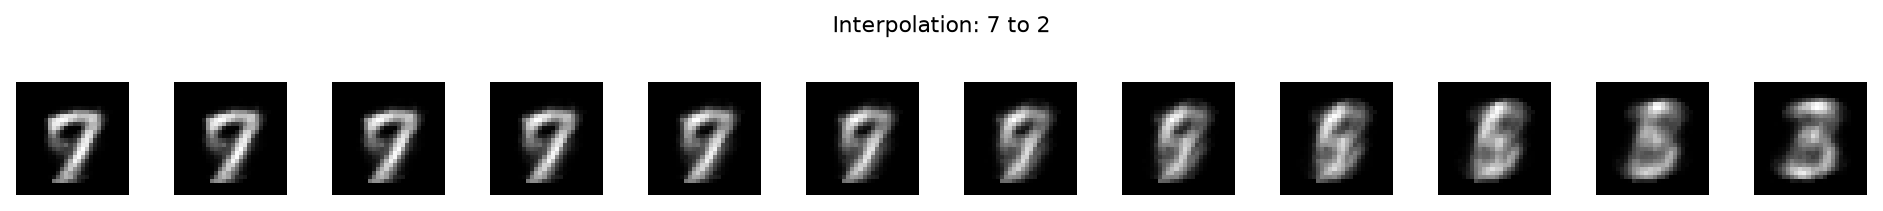

In [15]:
za, zb = ae2.encode(Xte[:1]), ae2.encode(Xte[1:2])
z_line = (za + (zb-za)*np.linspace(0, 1, 12)[:, None]).astype(np.float32)
show_grid(ae2.decode(z_line), f'Interpolation: {int(yte[0])} to {int(yte[1])}')


### References / 참고
Model implementation adapted from the supplied W02 notebook. MNIST data: TensorFlow/Keras public mirror, https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz.
Concepts: Goodfellow, Bengio & Courville, *Deep Learning*, Chapters 3 and 14, https://www.deeplearningbook.org/contents/prob.html and https://www.deeplearningbook.org/contents/autoencoders.html.
